In [ ]:
# Install dependencies (only needed on Google Colab or fresh environments)
%pip install vima-spatial tifffile imagecodecs -q

# VIMA for imaging data: preprocessing and QC

The [VIMA quick start](https://github.com/yakirr/vima/blob/main/demo/demo_quickstart_ST.ipynb) walks through a complete analysis of a spatial transcriptomics dataset. This notebook covers the one part of the workflow that is different for stain-based imaging technologies such as immunofluorescence (IF), CODEX, and immunohistochemistry: turning raw images into `vima`'s input format. Model training, association testing, and interpretation then work the same way as in the quick start.

Preprocessing has two steps:

1. **Rasterize and normalize** — downsample each image to `vima`'s 10-micron pixels, separate tissue from background, and normalize each pixel.
2. **Meta-markers and harmonization** — compress the markers into a few *meta-markers* with PCA, then use Harmony to remove technical differences between samples.

We then run some quality-control checks on the result.

The demo uses an immunofluorescence dataset of synovial biopsies from patients with rheumatoid arthritis: 27 images from 22 patients, each with 7 markers plus an autofluorescence channel.

In [3]:
import numpy as np
import glob, os, tifffile, vima

np.random.seed(0)
vima.settings.verbosity = 'minimal'

## Download the data

The raw images are 27 `.qptiff` files totaling about 30 GB.

In [ ]:
# Download the raw images (~30GB; this can take a while)
vima.download_zenodo("20087925", "./data/IF/raw")

## 1. Rasterize and normalize

For spatial transcriptomics, `vima` detects tissue and normalizes pixels on its own. Imaging technologies vary too much for one default to fit all, so we give `vima` three functions that describe our images:

1. **`load`** reads one image file and returns the sample's ID and the image as an array with dimensions (y, x, marker).
2. **`get_foreground`** takes one sample, already downsampled to `vima`'s resolution, and returns a mask that is `True` over tissue and `False` over background. `vima` provides `vima.pp.nonst.foreground_mask_if` for immunofluorescence, used here, and `vima.pp.nonst.foreground_mask_codex` for CODEX.
3. **`norm_by_background`** corrects each pixel for background signal, here autofluorescence. It takes a pixels × markers array and returns the names of the markers to keep along with their corrected values.

`vima` expects each file to hold a single sample (split slides that hold several samples first), with the channels in the same order in every file.

In [4]:
# the channels in each image, in order: 7 markers followed by an autofluorescence (AF) channel
markers = ['DAPI', 'CLIC5', 'CD34', 'HLADR', 'CD3', 'CD90', 'CD68', 'AF']
real_markers = markers[:-1]
neg_ctrls = markers[-1:]

# 1. read one image file
def load(path):
    sid = os.path.basename(path).split('.')[0] # sample ID = file name without extension
    with tifffile.TiffFile(path) as tif:
        data = tif.series[0].asarray()         # full-resolution image, shape (marker, y, x)
    return sid, np.ascontiguousarray(data.transpose(1, 2, 0)) # vima expects (y, x, marker)

# 2. separate tissue from background
def get_foreground(s):
    if s.name == '300-0529_Scan1':
        s = s.where(s.x < 12500, 0) # this sample has an artifact large enough to distort the
                                    # tissue threshold, so we blank out that part of the slide
    # vima's tissue detector for IF thresholds the ratio of marker signal to autofluorescence,
    # treating pixels with a ratio below 0.1 as not imaged and above 12 as artifacts
    return vima.pp.nonst.foreground_mask_if(s, real_markers, neg_ctrls, 0.1, 12, blur_width=5)

# 3. correct for autofluorescence by dividing each marker by the AF channel
def norm_by_AF(X):
    return real_markers, X[:, :-1] / (1 + X[:, -1])[:, None]

`prepare` applies these functions to every image. It downsamples each image from its original 0.5-micron pixels to 10-micron pixels by averaging, computes the tissue mask, and normalizes each tissue pixel: it corrects for autofluorescence, scales the pixel to a common total intensity, and log-transforms it. The results are written to `data/IF/10u`.

In [5]:
rawdatafiles = glob.glob('data/IF/raw/*.qptiff')
orig_pixel_size = 0.5 # microns per pixel in the raw images
resolution = 10       # microns per pixel for vima
outdir = f'data/IF/{resolution}u'

vima.pp.nonst.prepare(load=load,
                      filepaths=rawdatafiles,
                      orig_pixel_size=orig_pixel_size,
                      markers=markers,
                      get_foreground=get_foreground,
                      norm_by_background=norm_by_AF,
                      outdir=outdir,
                      pixel_size=resolution)

  0%|                                                                                                         …

  0%|                                                                                                         …

  0%|                                                                                                         …

## 2. Meta-markers and harmonization

`pca_pixels` compresses the markers into a few meta-markers with PCA, and `harmonize` uses Harmony to remove technical differences between samples, such as differences in staining intensity, from the meta-markers. The harmonized meta-markers are written to `data/IF/10u/metamarkers_5`. They are the input to model training.

The quick start uses 10 meta-markers (`vima`'s default) to summarize 140 genes. This panel has only 7 markers, so we use 5.

In [6]:
# convert markers to meta-markers
nmetamarkers = 5
repname = f'metamarkers_{nmetamarkers}'
allpixels_pca, pc_loadings = vima.pp.pca_pixels(outdir, repname, nmetamarkers=nmetamarkers)

# harmonize the meta-markers and write the results
harmpixels = vima.pp.harmonize(allpixels_pca)
vima.pp.write_harmonized(outdir, repname, harmpixels)

creating metapixels:   0%|                                                                                    …

pixels -> PCA space:   0%|                                                                                    …

write harmonized samples:   0%|                                                                               …

## 3. Quality control

Before training a model on these data, it's worth checking that preprocessing produced sensible results. `sanity_checks` draws three plots:

1. each harmonized meta-marker in one sample,
2. a histogram of each meta-marker across all samples, and
3. the first meta-marker in every third sample.

Things to look for:
- meta-marker patterns that follow the structure of the tissue,
- histograms without sharp spikes, which can point to an artifact, and
- no sample that looks strikingly different from the others.

If something looks off, inspect the raw image: an artifact can often be removed in `get_foreground`, as we did for one sample above, or the affected sample can be excluded.

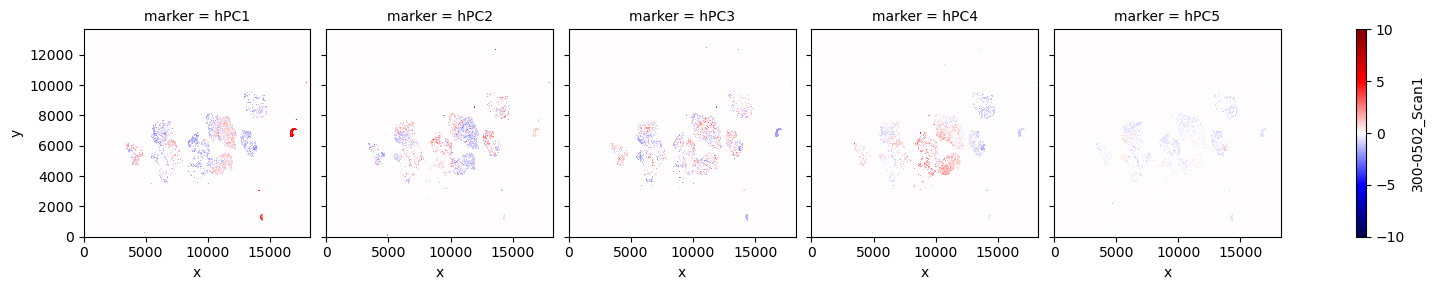

histogram of each pc:   0%|                                                                                   …

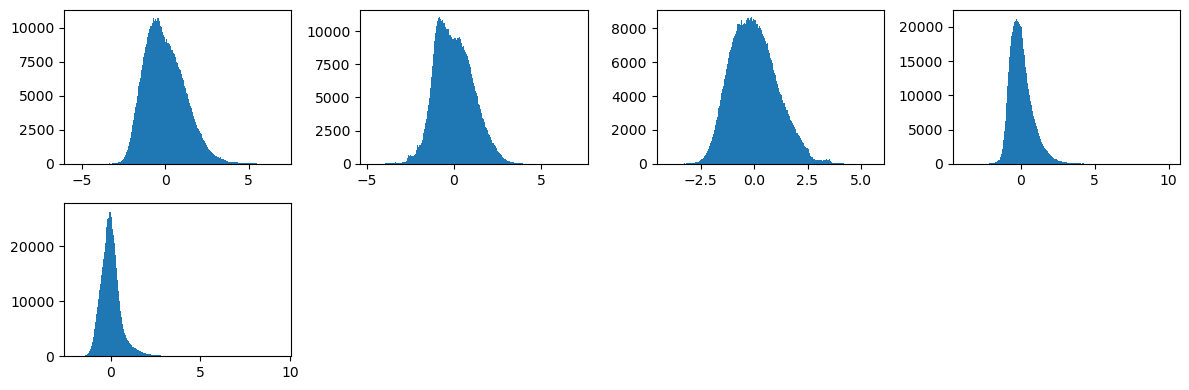

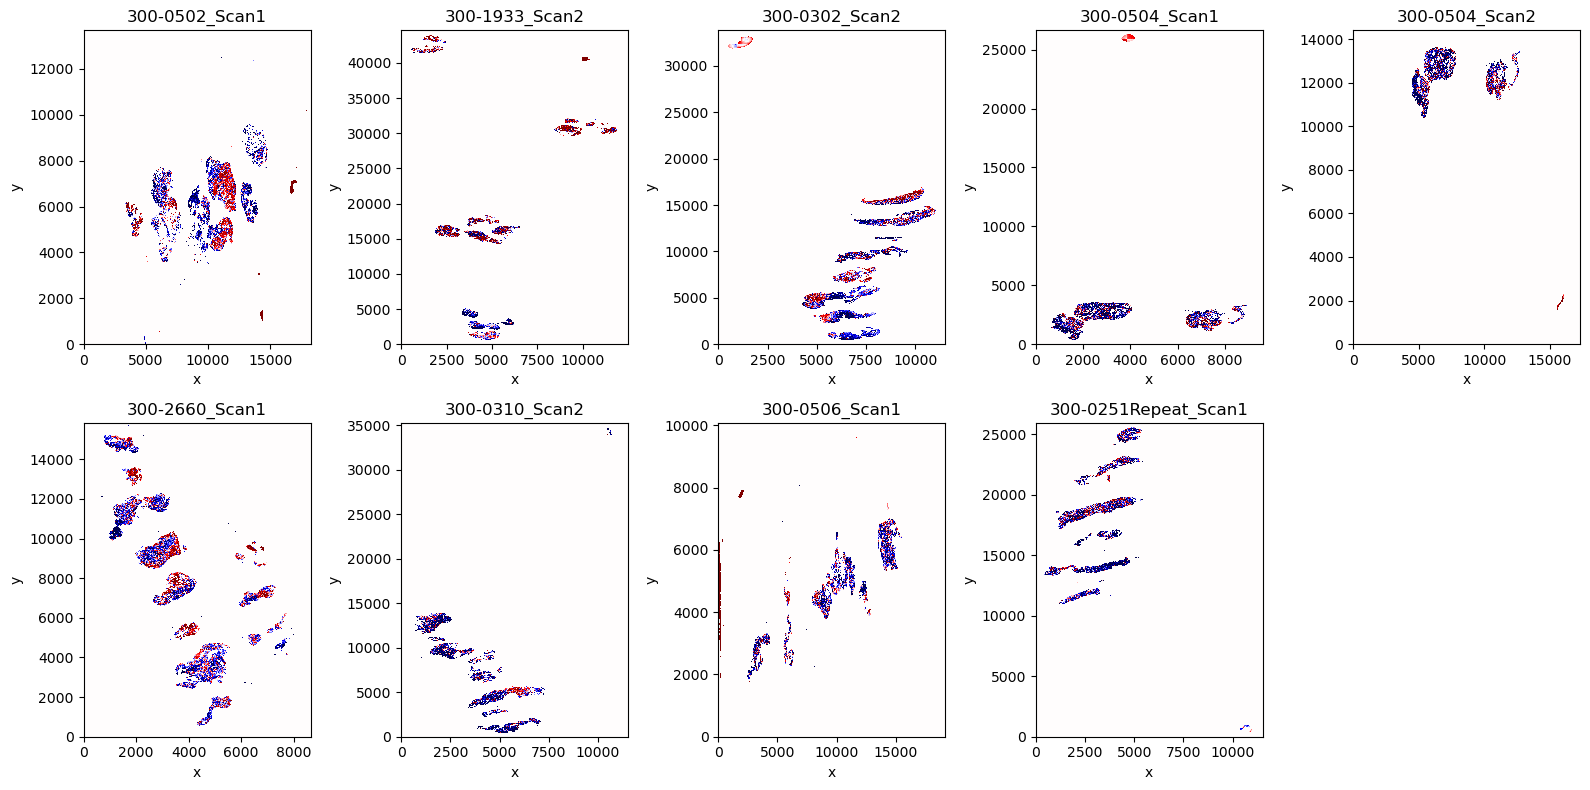

In [7]:
vima.pp.sanity_checks(outdir, repname)

## Next steps

From here the workflow is the same for every data type: train the model on these samples, compute patch fingerprints, test for case-control association, and interpret the results. The [quick start](https://github.com/yakirr/vima/blob/main/demo/demo_quickstart_ST.ipynb) shows each of these steps. The "Train the VAE and write the fingerprints" section of its appendix starts from preprocessed samples like these, which you can read in with `vima.read_samples('data/IF/10u/metamarkers_5/*.nc')`.